### Cricket batsman record

#### START -> [Strick rate, runs by boundries, percent run made boundaries] -> Summary -> END 

In [75]:
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI

In [76]:
load_dotenv()

True

In [77]:
chat_model = ChatOpenAI()

In [78]:
class BatsmanRecordState(TypedDict):
    runs: int
    balls: int
    sixes: int
    fours: int

    # output values
    strike_rate: float
    boundary_runs: int
    percent_boundary_runs: float
    summary: str

In [79]:
# Define graph
graph = StateGraph(BatsmanRecordState)

In [80]:
# Define python nodes
def get_strick_rate(state: BatsmanRecordState):
    sr = (state['runs']/state['balls'])*100
    state['strike_rate'] = sr
    return {'strike_rate': sr}

def get_boundary_runs(state: BatsmanRecordState):
    b_runs = (state['fours']*4)+(state['sixes']*6)
    state['boundary_runs'] = b_runs
    return {'boundary_runs': b_runs}

def get_perc_boundary_runs(state: BatsmanRecordState):
    percent = ((state['fours']*4)+(state['sixes']*6))/(state['runs'])*100
    state['percent_boundary_runs'] = percent
    return {'percent_boundary_runs': percent}

def get_summary(state: BatsmanRecordState):
    summary = f"""
    Batsman record based on {state['runs']} Runs, {state['balls']} Balls, {state['fours']} Fours, {state['sixes']} Sixes \n\n
    Strike Rate: {state['strike_rate']}\n
    Boundary Runs: {state['boundary_runs']}\n
    Percents of run made by boundaries: {state['percent_boundary_runs']}\n
    """
    state['summary'] = summary
    return {'summary': summary}

In [81]:
# Define nodes

graph.add_node('strick_rate', get_strick_rate)
graph.add_node('boundary_runs', get_boundary_runs)
graph.add_node('perc_boundary_runs', get_perc_boundary_runs)
graph.add_node('summary', get_summary)

In [82]:
# Define edges
graph.add_edge(START, "strick_rate")
graph.add_edge(START, "boundary_runs")
graph.add_edge(START, "perc_boundary_runs")
graph.add_edge("strick_rate", "summary")
graph.add_edge("boundary_runs", "summary")
graph.add_edge("perc_boundary_runs", "summary")
graph.add_edge("summary", END)

In [83]:
# Compile
workflow = graph.compile()

In [84]:
# Invokation
batsman_record = {'runs':100, 'balls': 50, 'sixes': 5, 'fours': 5}
record_summary = workflow.invoke(batsman_record)

print(record_summary)

{'runs': 100, 'balls': 50, 'sixes': 5, 'fours': 5, 'strike_rate': 200.0, 'boundary_runs': 50, 'percent_boundary_runs': 50.0, 'summary': '\n    Batsman record based on 100 Runs, 50 Balls, 5 Fours, 5 Sixes \n\n\n    Strike Rate: 200.0\n\n    Boundary Runs: 50\n\n    Percents of run made by boundaries: 50.0\n\n    '}


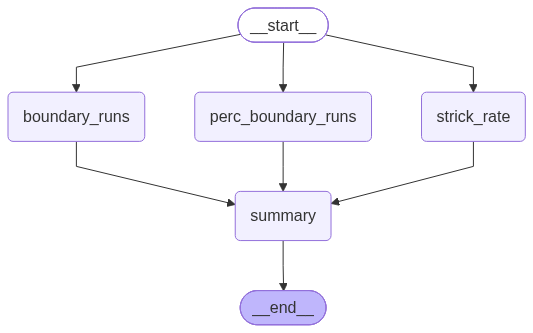

In [85]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())